In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial
import time

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex6_oerfm_2 import get_config
from constraints.continuous2d_oe_2 import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator_2_copy import SampleHole
from modules.solution_2_copy import (
    OddEvenDecompositionAverage2D,
    OddEvenDecompositionConstructor2D,
)
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(
    jnp.array([-0.2, -1.0, 0.2]), 3, axis=0)
params = {}
# eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
# bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
# eq_instance.shape, bc_instance.shape
time_start = time.time()

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    def q_sym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            + source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym1(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            + source_fn(x, y, -theta)
            - source_fn(x, y, -theta + jnp.pi)
        )

    def q_asym2(x, y, theta):
        return 0.5 * (
            source_fn(x, y, theta)
            - source_fn(x, y, theta + jnp.pi)
            - source_fn(x, y, -theta)
            + source_fn(x, y, -theta + jnp.pi)
        )

    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / jnp.pi * 2

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
            kn**2 * q_sym2(x, y, theta).squeeze(),
            kn * q_asym2(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = SampleHole(
    domain=domain, collocation_sizes=collocation_sizes, mode=mode
)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)
pts_left_hole, pts_right_hole, pts_lower_hole, pts_upper_hole = (
    sampler.pts_left_hole,
    sampler.pts_right_hole,
    sampler.pts_lower_hole,
    sampler.pts_upper_hole,
)

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
bc_left_hole, bc_right_hole, bc_lower_hole, bc_upper_hole = (
    vmap_bc_fn(*pts_left_hole),
    vmap_bc_fn(*pts_right_hole),
    vmap_bc_fn(*pts_lower_hole),
    vmap_bc_fn(*pts_upper_hole),
)

print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)

bc_left.shape: (4096, 2, 1024), bc_right.shape: (4096, 2, 1024), bc_lower.shape: (4096, 2, 1024), bc_upper.shape: (4096, 2, 1024)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (24000, 5, 1024)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (24000, 5)


In [12]:
def ex_solution_2d(x: jnp.ndarray, y: jnp.ndarray, theta: jnp.ndarray) -> jnp.ndarray:
    return jnp.exp(-x) * jnp.exp(-y)


vmap_ex_fn = vmap(jit(ex_solution_2d))

In [13]:
# Save the data
matrix_A = np.concatenate(
    [
        bc_left.reshape(-1, num_unknowns * 2),
        bc_right.reshape(-1, num_unknowns * 2),
        bc_lower.reshape(-1, num_unknowns * 2),
        bc_upper.reshape(-1, num_unknowns * 2),
        bc_left_hole.reshape(-1, num_unknowns * 2),
        bc_right_hole.reshape(-1, num_unknowns * 2),
        bc_lower_hole.reshape(-1, num_unknowns * 2),
        bc_upper_hole.reshape(-1, num_unknowns * 2),
        eq_int.reshape(-1, num_unknowns * 2),
    ],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta: 2,
         0] = 2 * vmap_ex_fn(*pts_left).squeeze()
vector_b[
    2 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_right).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_lower).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta: 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_upper).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta: 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 2 * bdy_size_y * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_left_hole).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 2 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_right_hole).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_lower_hole).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta: 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta: 2,
    0,
] = 2 * vmap_ex_fn(*pts_upper_hole).squeeze()

vector_b[
    4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta
    + 4 * bdy_size_y * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta:,
    0,
] = rhs_int.reshape(-1)

print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (185536, 1024), Vector b: (185536, 1)


In [14]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")
condition_number = np.linalg.cond(matrix_A)
print(f"A的条件数 = {condition_number:.2e}")

Matrix A 内存 1449.50 MB
Vector b 内存 1.42 MB
A的稀疏度 = 6.47% (零元素比例)
b的稀疏度 = 17.69% (零元素比例)
A的条件数 = 9.69e+08


In [15]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
time_end = time.time()
print(f"求解时间: {time_end - time_start:.2f} 秒")
print(f"Vector U: {vector_U.shape}")

求解时间: 333.57 秒
Vector U: (1024, 1)


In [16]:
error = matrix_A @ vector_U - vector_b
(
    np.abs(error).max(),
    np.abs(error).mean(),
)

(0.003051671119544963, 8.282863799953e-05)

In [17]:
# data = np.load("../src/data/weights.npz")
# vector_U = data["coefficients"]

In [18]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns * 2,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)
average = OddEvenDecompositionAverage2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [20]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / jnp.pi * 2

In [21]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [22]:
dummy_z = jnp.array([0, 0, 0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(
    f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}"
)  # f([0. 0. 0.]) = 1.000002714641632

f([0 0 0]) = 1.0001659185064586


In [23]:
def average_fn(x, y):
    quadratures = leggauss(num_quads, (0, jnp.pi / 2))
    pts, ws = quadratures
    weighted_sum = vmap(average.apply, [None, None, None, 0])(
        params, x, y, pts) @ ws
    return weighted_sum / jnp.pi * 2.0

In [24]:
def rho(x, y):
    return jnp.exp(-x) * jnp.exp(-y)

In [25]:
mesh_x, mesh_y = np.linspace(-1.0, 1.0, 129), np.linspace(-1.0, 1.0, 129)

X, Y = np.meshgrid(mesh_x, mesh_y)
rho_approx = vmap(aver_fn, [0, 0])(
    X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)
rho_ex = vmap(rho, [0, 0])(X, Y)
shape_matrix = np.ones(rho_ex.shape)
shape_matrix[
    len(mesh_x) // 3: len(mesh_x) // 3 * 2,
    len(mesh_y) // 3: len(mesh_y) // 3 * 2,
] = None
F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix
# mesh
# mesh_x, mesh_y = np.linspace(-1.0, 1.0, 129), np.linspace(-1.0, 1.0, 129)
# X, Y = np.meshgrid(mesh_x, mesh_y)

# hole_center = (0.0, 0.0)  # (x0, y0)
# hole_radius = 0.5  # r

# # 生成圆形掩码
# shape_matrix = np.ones(X.shape)

# dx = X - hole_center[0]
# dy = Y - hole_center[1]
# mask = dx**2 + dy**2 <= hole_radius**2
# shape_matrix[mask] = np.nan  # 或 None，如果matplotlib可以识别

# # 计算结果
# rho_approx_values = vmap(aver_fn, [0, 0])(X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(
#     X.shape
# )
# rho_ex_values = vmap(rho, [0, 0])(X, Y)

# # 应用掩码
# F, F_hat = rho_ex_values * shape_matrix, rho_approx_values * shape_matrix

In [26]:
# import matplotlib.pyplot as plt
# from matplotlib.patches import Circle

# font_format = {"size": 20}

# # 假设圆形洞圆心和半径
# hole_center = (0.0, 0.0)
# hole_radius = 0.5

# # mesh
# mesh_x, mesh_y = np.linspace(-1.0, 1.0, 129), np.linspace(-1.0, 1.0, 129)
# X, Y = np.meshgrid(mesh_x, mesh_y)

# # 圆形掩码
# shape_matrix = np.ones(X.shape)
# dx = X - hole_center[0]
# dy = Y - hole_center[1]
# mask = dx**2 + dy**2 <= hole_radius**2
# shape_matrix[mask] = np.nan  # np.nan 用于绘图透明

# # 计算函数值
# rho_approx = vmap(aver_fn, [0, 0])(
#     X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)
# rho_ex = vmap(rho, [0, 0])(X, Y)
# F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

# # 绘图函数，添加圆形洞


# def add_hole_shading(ax):
#     hole_patch = Circle(
#         hole_center,
#         hole_radius,
#         facecolor="#D3D3D3",
#         edgecolor="#9A9A9A",
#         linewidth=1.0,
#         linestyle="-",
#         alpha=0.45,
#         zorder=10,
#     )
#     ax.add_patch(hole_patch)


# # 参考解
# plt.figure(figsize=(8, 6))
# ax = plt.gca()
# plt.contourf(X, Y, F, 100, cmap="hot_r")
# add_hole_shading(ax)
# plt.xticks(size=12)
# plt.yticks(size=12)
# plt.xlabel(r"$x_1$", font_format)
# plt.ylabel(r"$x_2$", font_format)
# plt.colorbar(format="%.0e")

# # 近似解
# plt.figure(figsize=(8, 6))
# ax = plt.gca()
# plt.contourf(X, Y, F_hat, 100, cmap="hot_r")
# add_hole_shading(ax)
# plt.xticks(size=12)
# plt.yticks(size=12)
# plt.xlabel(r"$x_1$", font_format)
# plt.ylabel(r"$x_2$", font_format)
# plt.colorbar(format="%.0e")

# # 误差图
# error_plot = np.abs(F - F_hat)
# error_plot[mask] = np.nan  # 洞内部设置为nan
# plt.figure(figsize=(8, 6))
# ax = plt.gca()
# plt.contourf(X, Y, error_plot, 100, cmap="hot_r")
# add_hole_shading(ax)
# plt.xticks(size=12)
# plt.yticks(size=12)
# plt.xlabel(r"$x_1$", font_format)
# plt.ylabel(r"$x_2$", font_format)
# plt.colorbar(format="%.0e")

# plt.show()
# plt.close()

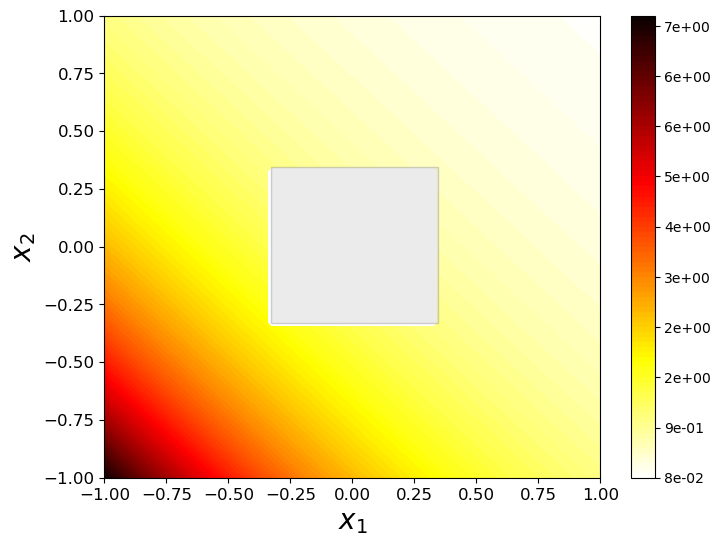

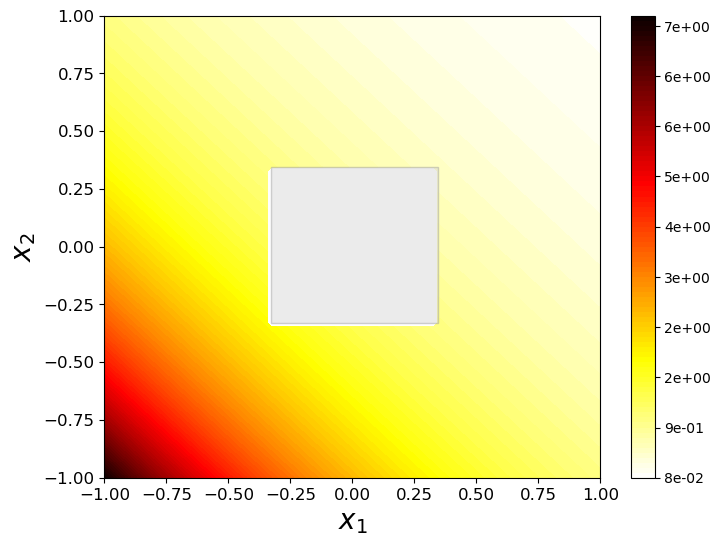

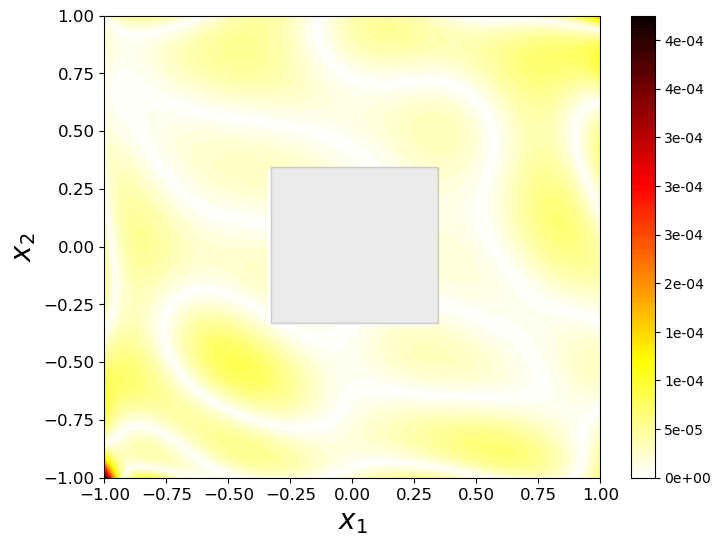

In [27]:
from matplotlib.patches import Rectangle

font_format = {"size": 20}
x1_l, x1_r = mesh_x[len(mesh_x) // 3], mesh_x[len(mesh_x) // 3 * 2]
x2_l, x2_r = mesh_y[len(mesh_y) // 3], mesh_y[len(mesh_y) // 3 * 2]
i1, i2 = len(mesh_x) // 3, len(mesh_x) // 3 * 2
j1, j2 = len(mesh_y) // 3, len(mesh_y) // 3 * 2


def add_hole_shading(ax):
    hole_patch = Rectangle(
        (x1_l, x2_l),
        x1_r - x1_l,
        x2_r - x2_l,
        facecolor="#D3D3D3",
        edgecolor="#9A9A9A",
        linewidth=1.0,
        linestyle="-",
        alpha=0.45,
        zorder=10,
    )
    ax.add_patch(hole_patch)


plt.figure(figsize=(8, 6))
ax = plt.gca()
plt.contourf(X, Y, F, 100, cmap="hot_r")
add_hole_shading(ax)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Reference solution", font_format)

plt.figure(figsize=(8, 6))
ax = plt.gca()
plt.contourf(X, Y, F_hat, 100, cmap="hot_r")
add_hole_shading(ax)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
# plt.title("OE-APRFM solution", font_format)

error_plot = np.abs(np.asarray(F) - np.asarray(F_hat)).astype(float)
error_plot[i1:i2, j1:j2] = np.nan

plt.figure(figsize=(8, 6))
ax = plt.gca()
plt.contourf(X, Y, error_plot, 100, cmap="hot_r")
add_hole_shading(ax)
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
# plt.title("Error", font_format)
# plt.savefig(f"./figures/aprfm2d_{kn:.1e}_contourf_ex4.png", dpi=300)
plt.show()
plt.close()

In [28]:
shape_matrix = np.ones(rho_ex.shape)
shape_matrix[
    len(mesh_x) // 3: len(mesh_x) // 3 * 2,
    len(mesh_y) // 3: len(mesh_y) // 3 * 2,
] = 0.0
F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

# # jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F), kn
# shape_matrix = np.ones(rho_ex.shape)
# mask = dx**2 + dy**2 <= hole_radius**2
# shape_matrix = jnp.where(mask, 0.0, shape_matrix)  # 圆形洞内部设为 0

# F, F_hat = rho_ex * shape_matrix, rho_approx * shape_matrix

jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F), kn

(Array(1.67859024e-05, dtype=float64), 0.001)

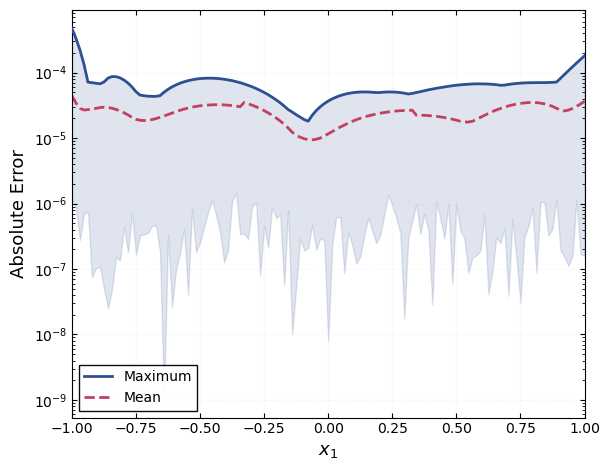

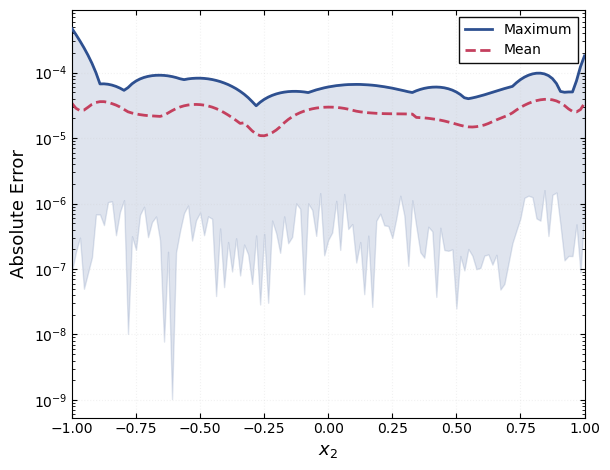

In [29]:
# ========== 2D Error Profiles: x1 / x2 / boundary-theta ==========
mesh_x_np = np.asarray(mesh_x)
mesh_y_np = np.asarray(mesh_y)
error = np.abs(np.asarray(F_hat) - np.asarray(F)).astype(float)
eps = 1e-16

i1, i2 = len(mesh_x_np) // 3, len(mesh_x_np) // 3 * 2
j1, j2 = len(mesh_y_np) // 3, len(mesh_y_np) // 3 * 2
error[i1:i2, j1:j2] = np.nan

colors = {
    "primary": "#2E5090",  # Deep blue
    "secondary": "#C4405E",  # Deep rose
    "tertiary": "#5D8AA8",  # Steel blue
    "quaternary": "#A8717A",  # Dusty rose
    "grid": "#CCCCCC",
    "light_blue": "#7BA3C4",
    "light_red": "#D17A8D",
}
# ---------- Figure 1: Error along x1 ----------
fig = plt.figure(figsize=(6.2, 4.8))
ax1 = fig.add_subplot(111)
error_max_x = np.nanmax(error, axis=0)
error_mean_x = np.nanmean(error, axis=0)
error_min_x = np.nanmin(error, axis=0)
ax1.semilogy(
    mesh_x_np,
    np.maximum(error_max_x, eps),
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
ax1.semilogy(
    mesh_x_np,
    np.maximum(error_mean_x, eps),
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
ax1.fill_between(
    mesh_x_np,
    np.maximum(error_min_x, eps),
    np.maximum(error_max_x, eps),
    alpha=0.15,
    color=colors["primary"],
    zorder=1,
)
ax1.set_xlabel(r"$x_1$", fontsize=13)
ax1.set_ylabel("Absolute Error", fontsize=13)
# ax1.set_title("Error along $x_1$", fontsize=13, pad=8)
ax1.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
ax1.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax1.tick_params(direction="in", which="both", top=True, right=True)
ax1.set_xlim([mesh_x_np[0], mesh_x_np[-1]])
plt.tight_layout()
plt.show()

# ---------- Figure 2: Error along x2 ----------
fig = plt.figure(figsize=(6.2, 4.8))
ax2 = fig.add_subplot(111)
error_max_y = np.nanmax(error, axis=1)
error_mean_y = np.nanmean(error, axis=1)
error_min_y = np.nanmin(error, axis=1)
ax2.semilogy(
    mesh_y_np,
    np.maximum(error_max_y, eps),
    "-",
    color=colors["primary"],
    linewidth=2,
    label="Maximum",
    zorder=3,
)
ax2.semilogy(
    mesh_y_np,
    np.maximum(error_mean_y, eps),
    "--",
    color=colors["secondary"],
    linewidth=2,
    label="Mean",
    zorder=2,
)
ax2.fill_between(
    mesh_y_np,
    np.maximum(error_min_y, eps),
    np.maximum(error_max_y, eps),
    alpha=0.15,
    color=colors["primary"],
    zorder=1,
)
ax2.set_xlabel(r"$x_2$", fontsize=13)
ax2.set_ylabel("Absolute Error", fontsize=13)
# ax2.set_title("Error along $x_2$", fontsize=13, pad=8)
ax2.legend(
    loc="best",
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    fancybox=False,
    shadow=False,
)
ax2.grid(True, alpha=0.25, linestyle=":", linewidth=0.8, color=colors["grid"])
ax2.tick_params(direction="in", which="both", top=True, right=True)
ax2.set_xlim([mesh_y_np[0], mesh_y_np[-1]])
plt.tight_layout()
plt.show()